In [1]:
import numpy as np
from astropy.table import Table
from astropy.table import join
from astropy.table import vstack
from astropy.table import Column

from astropy.io import fits
import pandas as pd
from astropy.cosmology import Planck18
from scipy.spatial import Delaunay
from sklearn.metrics import mutual_info_score

import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Patch
matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
# plt.style.use('dark_background')
from matplotlib.colors import LogNorm
import seaborn as sns

import warnings
from astropy.units import UnitsWarning

warnings.simplefilter('ignore', UnitsWarning)

In [2]:
base = '/pscratch/sd/v/vtorresg/cosmic-web/edr'

In [4]:
ls = []
for zone in range(20):
    temp = Table.read(f'{base}/probabilities/zone_{zone:02d}_probability.fits.gz')
    temp.add_column(Column([zone]*len(temp), name='ZONE'))
    ls.append(temp)

t_edr = vstack(ls)
# t_edr

In [5]:
t = Table.read('/global/cfs/cdirs/desi/public/edr/vac/edr/stellar-mass-emline/v1.0/edr_galaxy_stellarmass_lineinfo_v1.0.fits')
# t

In [22]:
t_sub = t['TARGETID', 'SED_SFR', 'SED_MASS', 'SED_SFRERR', 'SED_MASSERR', 
          'Z', 'ZERR', 'FLUX_G', 'FLUX_R', 'SED_Z', 'OIII5007_FLUX', 'HBETA_FLUX',
          'NII6583_FLUX', 'HALPHA_FLUX', 'OIII5007_FLUXERR', 'HBETA_FLUXERR',
           'NII6583_FLUXERR', 'HALPHA_FLUXERR'].copy()

In [23]:
score = np.array(t_sub['ZERR'])

order = np.lexsort((score, t_sub['TARGETID']))
t_sorted = t_sub[order]

tid = np.array(t_sorted['TARGETID'])
keep = np.ones(len(t_sorted), dtype=bool)
keep[1:] = tid[1:] != tid[:-1]
t_best = t_sorted[keep]

In [24]:
t_all = join(t_edr, t_best, keys='TARGETID', join_type='inner')

In [25]:
bgs = t_all[t_all['TRACERTYPE'] == 'BGS_ANY']
# elg = t_all[t_all['TRACERTYPE'] == 'ELG']
lrg = t_all[t_all['TRACERTYPE'] == 'LRG']
# qso = t_all[t_all['TRACERTYPE'] == 'QSO']

In [26]:
bgs_mask = ((bgs['Z']<0.6) & (np.log10(bgs['SED_SFR'])>-4.0) & (np.log10(bgs['SED_SFR'])<3.0))
bgs = bgs[bgs_mask]

lrg_mask = ((lrg['Z']<1.1) & (lrg['Z']>0.4) & (np.log10(lrg['SED_SFR'])>-4.0) & (np.log10(lrg['SED_SFR'])<2.0))
lrg = lrg[lrg_mask]

### Z
https://iopscience.iop.org/article/10.3847/1538-3881/ae1129

$$\mathrm{O3N2}=\frac{[\mathrm{OIII}]5007/H\beta}{[\mathrm{NII}]6583/H\alpha}$$

$$\log(\mathrm{O3N2})=0.281−4.765x−2.268x^2$$

$$x=12+\log(O/H)−8.69$$

$$SNR=\frac{FLUX}{FLUXERR}$$

$$\frac{NII6583\,FLUX}{NII6583\,FLUXERR}>3$$

In [44]:
d = bgs.to_pandas()

In [45]:
cols = [
        "OIII5007_FLUX", "OIII5007_FLUXERR",
        "HBETA_FLUX",    "HBETA_FLUXERR",
        "NII6583_FLUX",  "NII6583_FLUXERR",
        "HALPHA_FLUX",   "HALPHA_FLUXERR",
    ]

mask = np.ones(len(d), dtype=bool)
for c in cols:
    mask &= np.isfinite(d[c])

In [46]:
mask &= (d["OIII5007_FLUX"] > 0) & (d["OIII5007_FLUXERR"] > 0)
mask &= (d["HBETA_FLUX"]    > 0) & (d["HBETA_FLUXERR"]    > 0)
mask &= (d["NII6583_FLUX"]  > 0) & (d["NII6583_FLUXERR"]  > 0)
mask &= (d["HALPHA_FLUX"]   > 0) & (d["HALPHA_FLUXERR"]   > 0)

In [47]:
d["SNR_OIII5007"] = d["OIII5007_FLUX"] / d["OIII5007_FLUXERR"]
d["SNR_HBETA"] = d["HBETA_FLUX"] / d["HBETA_FLUXERR"]
d["SNR_NII6583"] = d["NII6583_FLUX"] / d["NII6583_FLUXERR"]
d["SNR_HALPHA"] = d["HALPHA_FLUX"] / d["HALPHA_FLUXERR"]

In [48]:
snr_min = 3

In [49]:
mask &= (d["SNR_NII6583"] > snr_min)
mask &= (d["SNR_OIII5007"] > snr_min)
mask &= (d["SNR_HBETA"] > snr_min)
mask &= (d["SNR_HALPHA"] > snr_min)

In [50]:
d["O3N2_ratio"] = np.nan
d["LOG_O3N2"] = np.nan
d["OH12_O3N2"] = np.nan

In [51]:
o3n2_ratio = (
    (d["OIII5007_FLUX"][mask] / d["HBETA_FLUX"][mask]) /
    (d["NII6583_FLUX"][mask] / d["HALPHA_FLUX"][mask])
)

y = np.log10(o3n2_ratio)

d.loc[mask, "O3N2_ratio"] = o3n2_ratio
d.loc[mask, "LOG_O3N2"] = y

In [52]:
# y = 0.281 - 4.765 x - 2.268 x^2
#
# => 2.268 x^2 + 4.765 x + (y - 0.281) = 0

In [53]:
a = 2.268
b = 4.765
c = y - 0.281

disc = b**2 - 4*a*c

valid_disc = disc >= 0

x_sol1 = np.full(len(y), np.nan)
x_sol2 = np.full(len(y), np.nan)

sqrt_disc = np.sqrt(disc[valid_disc])

x_sol1[valid_disc] = (-b + sqrt_disc) / (2*a)
x_sol2[valid_disc] = (-b - sqrt_disc) / (2*a)

oh1 = x_sol1 + 8.69
oh2 = x_sol2 + 8.69

In [54]:
oh = np.full(len(y), np.nan)

r1 = (oh1 > 7.0) & (oh1 < 10.0)
r2 = (oh2 > 7.0) & (oh2 < 10.0)

oh[r1 & ~r2] = oh1[r1 & ~r2]

oh[r2 & ~r1] = oh2[r2 & ~r1]

both = r1 & r2
choose1 = np.abs(oh1[both] - 8.7) < np.abs(oh2[both] - 8.7)
oh_both = np.where(choose1, oh1[both], oh2[both])
oh[both] = oh_both

d.loc[mask, "OH12_O3N2"] = oh

In [76]:
df = d

In [77]:
pcols = ['PVOID', 'PSHEET', 'PFILAMENT', 'PKNOT']

df[pcols] = df[pcols].apply(pd.to_numeric, errors='coerce')
higher_col = df[pcols].idxmax(axis=1)

In [78]:
col_to_class = {'PVOID': 'Void', 
                'PSHEET': 'Sheet',
                'PFILAMENT': 'Filament',
                'PKNOT': 'Knot'}

df['ENV'] = higher_col.map(col_to_class)
df['P_MAX'] = df[pcols].max(axis=1)

In [79]:
df['GR'] = -2.5 * np.log10(df['FLUX_G']/df['FLUX_R'])

/global/common/software/nersc/pe/conda-envs/26.1.0/python-3.13/nersc-python/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [80]:
envs = {'Void': df[df['ENV']=='Void'],
        'Sheet': df[df['ENV']=='Sheet'],
        'Filament': df[df['ENV']=='Filament'],
        'Knot': df[df['ENV']=='Knot']}

In [81]:
def binned_median_with_bootstrap(x, y, bins, nboot=50, min_n=10, seed=0):
    rng = np.random.default_rng(seed)

    x = np.asarray(x)
    y = np.asarray(y)

    x_mid, y_med, y_err, n_inbin = [], [], [], []

    for i in range(len(bins) - 1):
        lo, hi = bins[i], bins[i+1]
        m = (x >= lo) & (x < hi) & np.isfinite(x) & np.isfinite(y)

        yi = y[m]
        ni = yi.size
        if ni < min_n:
            continue

        med = np.median(yi)

        # bootstrapppp
        boots = []
        for _ in range(nboot):
            sample = rng.choice(yi, size=ni, replace=True)
            boots.append(np.median(sample))
        err = np.std(boots, ddof=1)

        x_mid.append(0.5 * (lo + hi))
        y_med.append(med)
        y_err.append(err)
        n_inbin.append(ni)

    return np.array(x_mid), np.array(y_med), np.array(y_err), np.array(n_inbin)

In [82]:
def plot_binned_by_env(ax, envs, xcol, ycol, bins, nboot=50, min_n=10, xlabel='', ylabel='',
                       use_clean_df=False):
    for name, dsub in envs.items():
        x = dsub[xcol].to_numpy()
        y = dsub[ycol].to_numpy()

        xm, ym, ye, nbin = binned_median_with_bootstrap(
            x, y, bins, nboot=nboot, min_n=min_n, seed=0)

        if len(xm) == 0:
            continue

        ax.errorbar(xm, ym, yerr=ye, marker='o', ms=3.5, lw=1.2, capsize=2, label=name)

    ax.grid(lw=0.2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

In [83]:
n_binss = 15

In [84]:
df = df.copy()
df['LOGM'] = np.log10(df['SED_MASS'])

m = (df['FLUX_G'] > 0) & (df['FLUX_R'] > 0)
df['GR'] = np.nan
df.loc[m, 'GR'] = -2.5 * np.log10(df.loc[m, 'FLUX_G'] / df.loc[m, 'FLUX_R'])

In [85]:
df['LOGSFR'] = np.log10(df['SED_SFR'].clip(lower=1e-5))
df['LOGSSFR'] = df['LOGSFR'] - df['LOGM']  # log(SFR/M*) = log(sSFR)

In [86]:
env_order = ['Void', 'Sheet', 'Filament', 'Knot']

envs_all = {e: df[df['ENV'] == e] for e in env_order}
# envs_met = {e: df_met[df_met['ENV'] == e] for e in env_order}

In [87]:
bins_M_all = np.linspace(df['LOGM'].min(), df['LOGM'].max(), n_binss)
# bins_M_met = np.linspace(df_met['LOGM'].min(), df_met['LOGM'].max(), n_binss)

bins_SFR = np.quantile(df['LOGSFR'], np.linspace(0,1,n_binss))
bins_SSFR = np.quantile(df['LOGSSFR'], np.linspace(0,1,n_binss))

In [88]:
mask_ = np.isfinite(df["GR"]) & np.isfinite(df["SED_Z"])
df = df[mask_]

In [89]:
envs = {e: df[df['ENV']==e] for e in env_order}

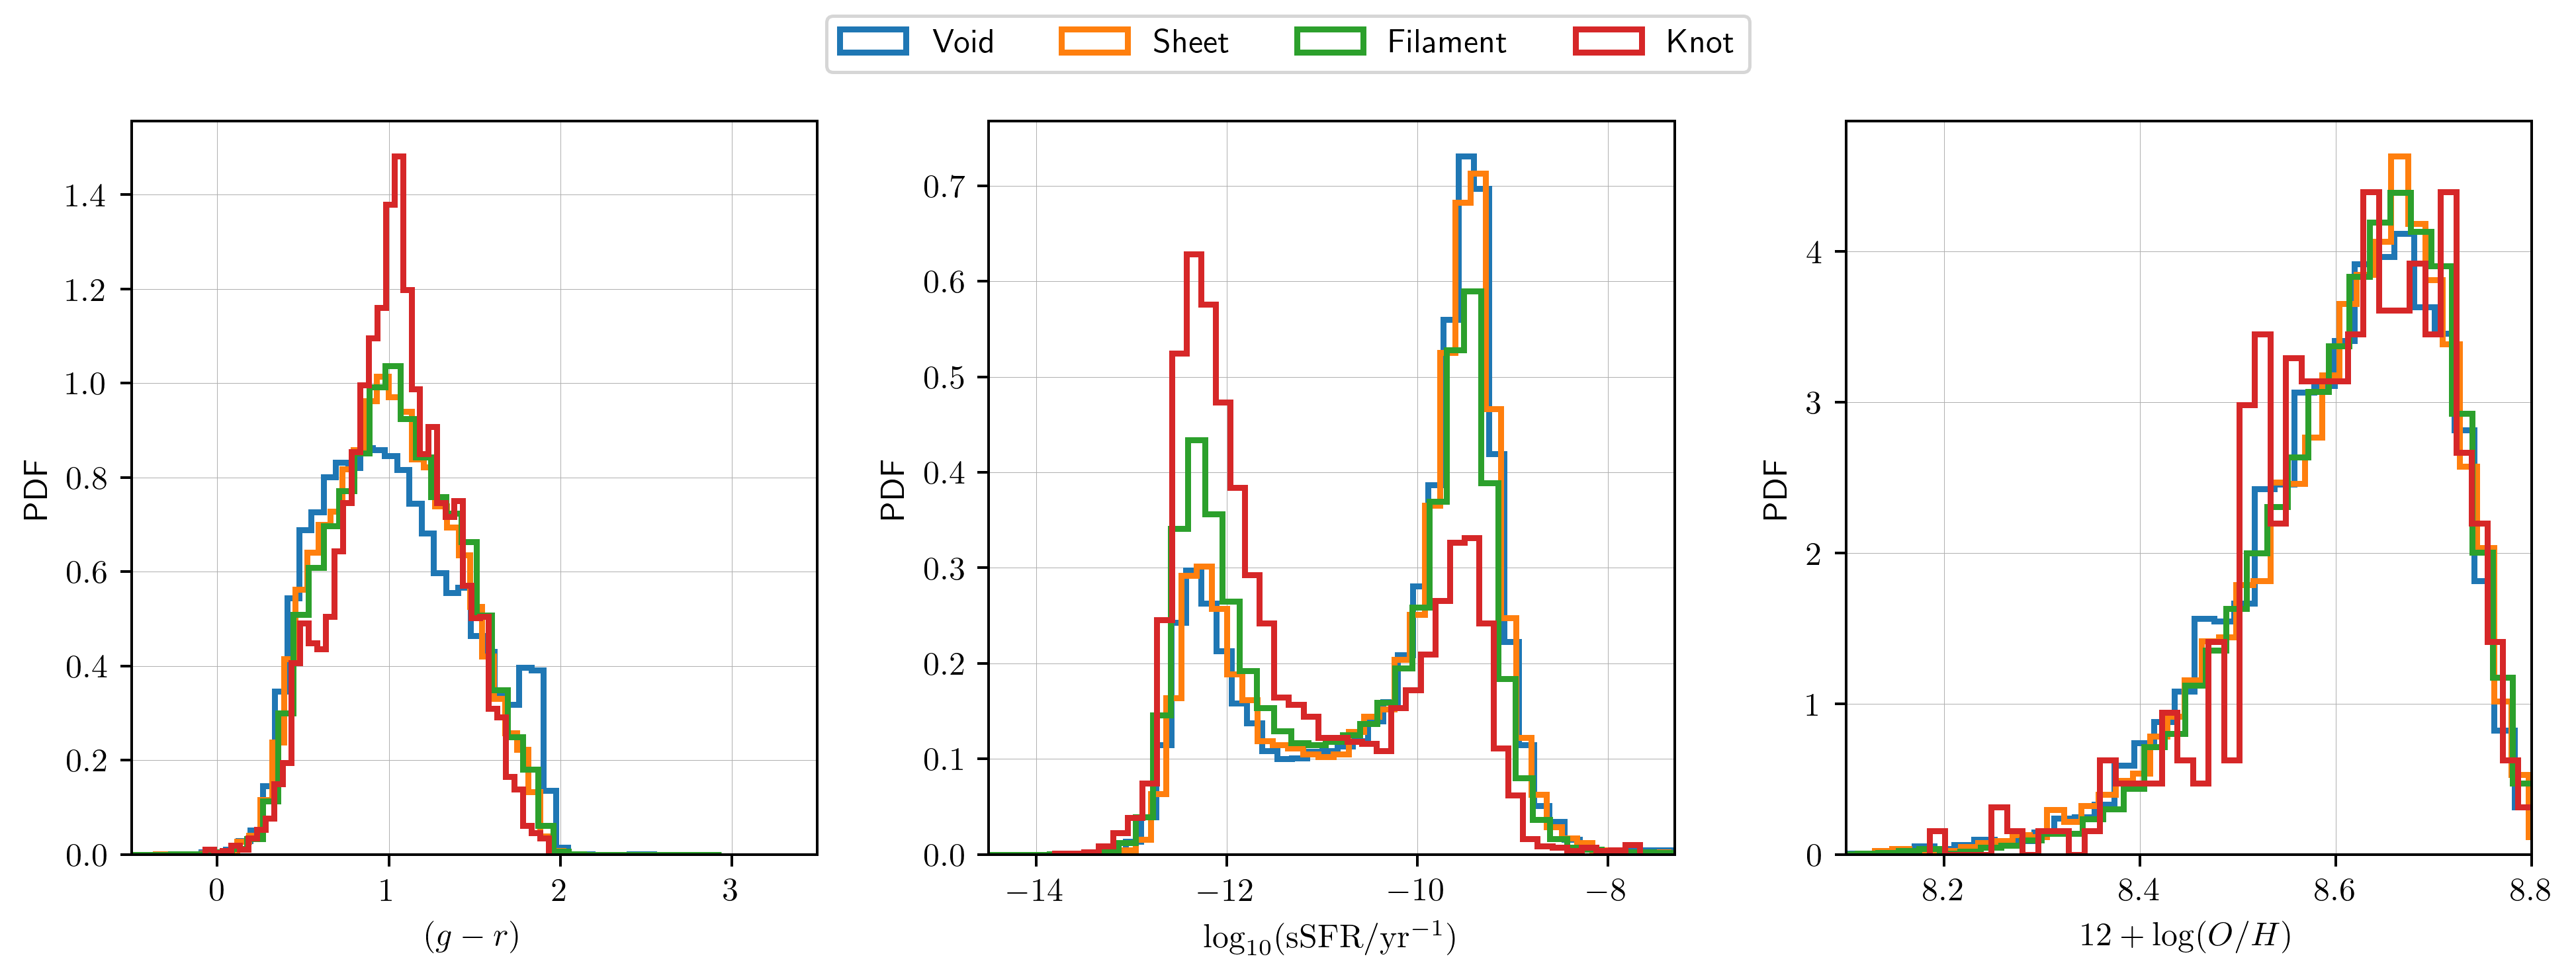

In [90]:
fig, axes = plt.subplots(1,3, figsize=(13,4))
plt.subplots_adjust(wspace=0.25)

for e, d in envs.items():
    x = d['GR'].to_numpy()
    x = x[np.isfinite(x)]
    axes[0].hist(x, bins=40, density=True, histtype='step', lw=1.8, label=e)

axes[0].set_xlabel(r'$(g-r)$')
axes[0].set_ylabel('PDF')
axes[0].grid(lw=0.2)
axes[0].set_xlim(-0.5,3.5)

for e, d in envs.items():
    x = d['LOGSSFR'].to_numpy()
    x = x[np.isfinite(x)]
    axes[1].hist(x, bins=40, density=True, histtype='step', lw=1.8, label=e)
axes[1].set_xlabel(r'$\log_{10}(\mathrm{sSFR}/\mathrm{yr}^{-1})$')
axes[1].set_ylabel('PDF')
axes[1].grid(lw=0.2)
axes[1].set_xlim(-14.5,-7.3)

for e, d in envs.items():
    x = d['OH12_O3N2'].to_numpy()
    x = x[np.isfinite(x)]
    axes[2].hist(x, bins=40, density=True, histtype='step', lw=1.8, label=e)
    
axes[2].set_xlabel(r'$12+\log(O/H)$')
axes[2].set_ylabel('PDF')
axes[2].grid(lw=0.2)
axes[2].set_xlim(8.1, 8.8)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=True)

# plt.savefig('./plots/pdf_env.png', dpi=360)
plt.show()

In [91]:
# Depende mas de la masa que del entorno?